In [7]:
# WHAT I AM DOING: Re-loading the corrected Logistic Regression model from GitHub
!git clone https://github.com/ebrimakfatty/datascienceprojectweek5.git /content/week6_data
import joblib
model = joblib.load('/content/week6_data/logistic_regression_model.pkl')
print(type(model))

Cloning into '/content/week6_data'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13 (delta 1), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 1.61 MiB | 10.91 MiB/s, done.
Resolving deltas: 100% (1/1), done.
<class 'sklearn.linear_model._logistic.LogisticRegression'>


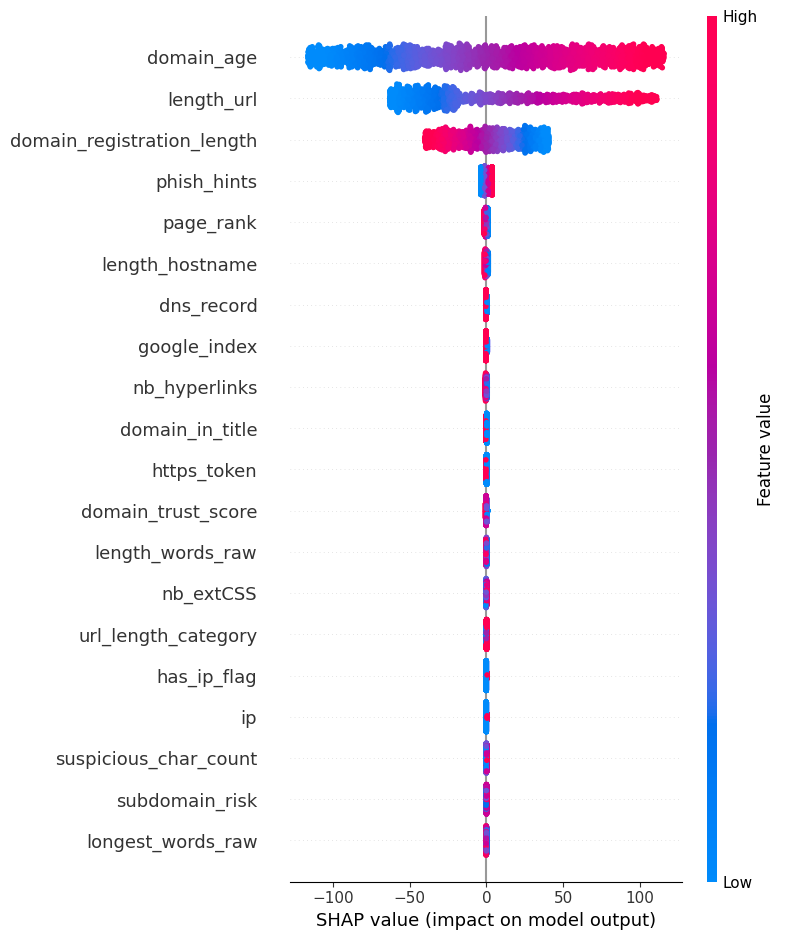

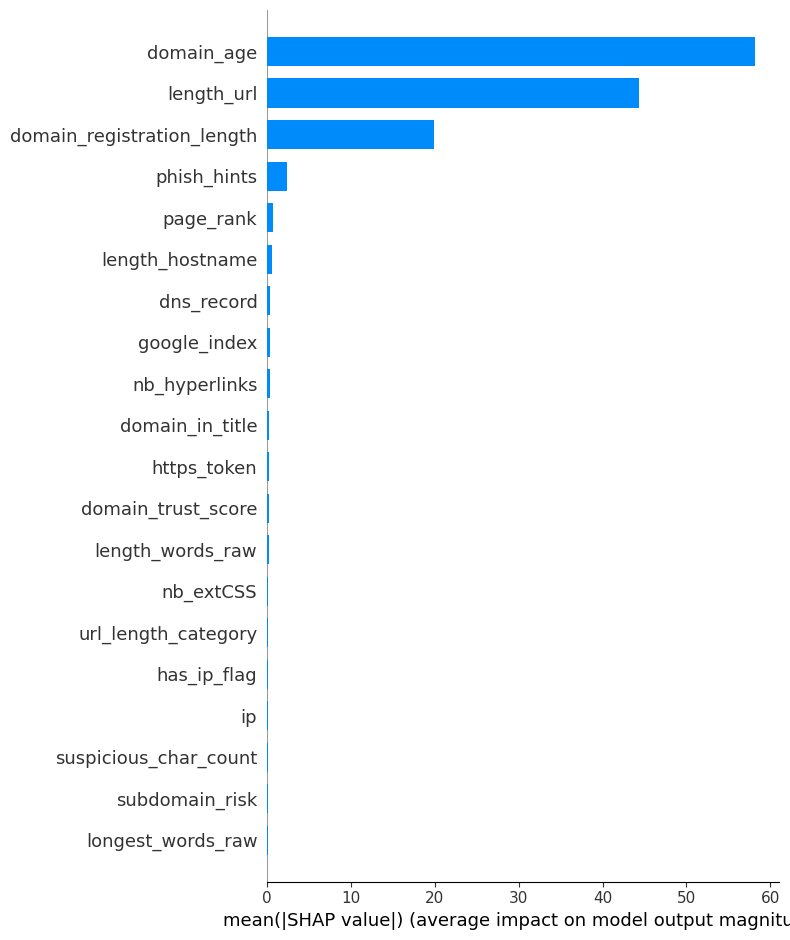

In [8]:
# WHAT I AM DOING: Using SHAP's LinearExplainer to explain global feature
# importance across the test set, now using the correct Logistic Regression model

explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# WHAT I AM DOING: Explaining one individual prediction in detail to use as a case study

sample_idx = 0
sample = X_test.iloc[[sample_idx]]
prediction = model.predict(sample)[0]
prediction_proba = model.predict_proba(sample)[0]

print(f"Sample {sample_idx} | Predicted: {prediction} | Probability: {prediction_proba}")

Sample 0 | Predicted: 1 | Probability: [0. 1.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [10]:
# WHAT I AM DOING: Getting the SHAP values for this specific sample
# to see which features drove the phishing prediction

sample_shap_values = explainer.shap_values(sample)
expected_value = explainer.expected_value

# Print the top contributing features for this one prediction
import numpy as np
contributions = list(zip(feature_names, sample_shap_values[0]))
contributions_sorted = sorted(contributions, key=lambda x: abs(x[1]), reverse=True)

print(f"Sample {sample_idx} prediction: {'PHISHING' if prediction == 1 else 'LEGITIMATE'}")
print(f"Base value (expected): {expected_value:.4f}\n")
print("Top 5 contributing features:")
for feat, val in contributions_sorted[:5]:
    direction = "→ pushes toward PHISHING" if val > 0 else "→ pushes toward LEGITIMATE"
    print(f"  {feat}: {val:.4f}  {direction}")

Sample 0 prediction: PHISHING
Base value (expected): 151.5221

Top 5 contributing features:
  domain_age: -111.5403  → pushes toward LEGITIMATE
  length_url: 98.8200  → pushes toward PHISHING
  domain_registration_length: -20.3190  → pushes toward LEGITIMATE
  phish_hints: 1.2953  → pushes toward PHISHING
  length_hostname: -0.8243  → pushes toward LEGITIMATE


In [11]:
# WHAT I AM DOING: Using LIME to independently verify SHAP's local explanation

import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['legitimate', 'phishing'],
    mode='classification'
)

lime_exp = lime_explainer.explain_instance(
    data_row=sample.values[0],
    predict_fn=model.predict_proba,
    num_features=5
)

for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

domain_age <= 1725.00: -0.1214
domain_registration_length > 2235.25: -0.0702
length_url > 166.00: 0.0457
length_hostname > 46.00: -0.0103
ratio_nullHyperlinks <= 0.12: 0.0083


In [12]:
# WHAT I AM DOING: Saving the SHAP explainer so the deployed app can use it later

import pickle
with open('shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)
print("SHAP explainer saved")

SHAP explainer saved


In [13]:
# WHAT I AM DOING: Pushing the SHAP explainer and plots to GitHub
!git clone https://github.com/ebrimakfatty/datascienceprojectweek5.git /content/week6_push
import shutil
for f in ['shap_explainer.pkl', 'shap_summary_plot.png', 'shap_bar_plot.png']:
    shutil.copy(f, f'/content/week6_push/{f}')
%cd /content/week6_push
!git config user.email "you@example.com"
!git config user.name "ebrimakfatty"
!git add shap_explainer.pkl shap_summary_plot.png shap_bar_plot.png
!git commit -m "Add Week6 SHAP explainer and plots"

Cloning into '/content/week6_push'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13 (delta 1), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 1.61 MiB | 11.69 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/week6_push
[main 8e4dcb6] Add Week6 SHAP explainer and plots
 3 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 shap_bar_plot.png
 create mode 100644 shap_explainer.pkl
 create mode 100644 shap_summary_plot.png


In [ ]:
%%writefile app.py
from flask import Flask, request, jsonify
import joblib
import pickle

app = Flask(__name__)

model = joblib.load('logistic_regression_model.pkl')
with open('shap_explainer.pkl', 'rb') as f:
    shap_explainer = pickle.load(f)

FEATURE_NAMES = list(pd.read_csv('X_train.csv').columns)

@app.route('/', methods=['GET'])
def home():
    return jsonify({"message": "Phishing Detection API is running", "status": "healthy"})

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        features = data.get('features')
        if features is None or len(features) != len(FEATURE_NAMES):
            return jsonify({"error": f"Expected {len(FEATURE_NAMES)} features"}), 400

        X = pd.DataFrame([features], columns=FEATURE_NAMES)
        prediction = int(model.predict(X)[0])
        probability = model.predict_proba(X)[0].tolist()

        return jsonify({
            "prediction": prediction,
            "label": "phishing" if prediction == 1 else "legitimate",
            "probability": probability
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route('/explain', methods=['POST'])
def explain():
    try:
        data = request.get_json()
        features = data.get('features')
        X = pd.DataFrame([features], columns=FEATURE_NAMES)

        shap_vals = shap_explainer.shap_values(X)[0]
        all_features = sorted(zip(FEATURE_NAMES, shap_vals), key=lambda x: abs(x[1]), reverse=True)

        explanation = [
            {"feature": f, "shap_value": round(float(v), 4),
             "direction": "increases_phishing_risk" if v > 0 else "decreases_phishing_risk"}
            for f, v in all_features[:5]
        ]
        return jsonify({"explanation": explanation})
    except Exception as e:
        return jsonify({"error": str(e)}), 500

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)

Writing app.py


In [19]:
# WHAT I AM DOING: Installing a modern, working tunnel tool (pyngrok) to replace
# the broken flask_ngrok library
!pip install pyngrok -q

In [21]:
# WHAT I AM DOING: Authenticating pyngrok with my account token
from pyngrok import ngrok
ngrok.set_auth_token("3FcjRARfttyVmyy7duNqsYLkh0N_6DgB9bKkguRrHZiqQf65k")

In [24]:
# WHAT I AM DOING: Running Flask in a background thread so other cells can run while it's live
from pyngrok import ngrok
import threading
import importlib
import app as flask_app_module
importlib.reload(flask_app_module)

public_url = ngrok.connect(5000)
print("Public URL:", public_url)

def run_app():
    flask_app_module.app.run(port=5000)

thread = threading.Thread(target=run_app)
thread.start()

Public URL: NgrokTunnel: "https://carrousel-fading-ditch.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app 'app'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


In [25]:
# WHAT I AM DOING: Testing the live /predict endpoint with one real test sample
import requests

sample_features = X_test.iloc[0].tolist()

response = requests.post(
    "https://carrousel-fading-ditch.ngrok-free.dev/predict",
    json={"features": sample_features}
)
print(response.json())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
INFO:werkzeug:127.0.0.1 - - [25/Jun/2026 10:02:52] "POST /predict HTTP/1.1" 200 -


{'label': 'phishing', 'prediction': 1, 'probability': [0.0, 1.0]}


In [26]:
# WHAT I AM DOING: Testing the live /explain endpoint to confirm SHAP explanations work through the API

response = requests.post(
    "https://carrousel-fading-ditch.ngrok-free.dev/explain",
    json={"features": sample_features}
)
print(response.json())

INFO:werkzeug:127.0.0.1 - - [25/Jun/2026 10:03:20] "POST /explain HTTP/1.1" 200 -


{'explanation': [{'direction': 'decreases_phishing_risk', 'feature': 'domain_age', 'shap_value': -111.5403}, {'direction': 'increases_phishing_risk', 'feature': 'length_url', 'shap_value': 98.82}, {'direction': 'decreases_phishing_risk', 'feature': 'domain_registration_length', 'shap_value': -20.319}, {'direction': 'increases_phishing_risk', 'feature': 'phish_hints', 'shap_value': 1.2953}, {'direction': 'decreases_phishing_risk', 'feature': 'length_hostname', 'shap_value': -0.8243}]}


In [ ]:
%%writefile streamlit_app.py
import streamlit as st
import pandas as pd
import joblib
import pickle
import numpy as np

st.set_page_config(page_title="Phishing URL Detector", layout="wide")

@st.cache_resource
def load_artifacts():
    model = joblib.load('logistic_regression_model.pkl')
    with open('shap_explainer.pkl', 'rb') as f:
        explainer = pickle.load(f)
    feature_names = list(pd.read_csv('X_train.csv').columns)
    return model, explainer, feature_names

model, explainer, feature_names = load_artifacts()

st.title("🔍 Phishing Website Detection")
st.write("Upload a CSV of feature values, or pick a sample row, to get a prediction with explanation.")

mode = st.radio("Input method", ["Upload CSV", "Pick a test sample"])
input_df = None

if mode == "Upload CSV":
    uploaded_file = st.file_uploader("Upload CSV with feature columns", type="csv")
    if uploaded_file:
        input_df = pd.read_csv(uploaded_file)
        st.write("Preview:", input_df.head())
else:
    test_df = pd.read_csv('X_test.csv')
    row_idx = st.number_input("Pick a test row index", 0, len(test_df)-1, 0)
    input_df = test_df.iloc[[row_idx]]
    st.write("Selected row:", input_df)

if input_df is not None and st.button("Predict"):
    X = input_df[feature_names]
    preds = model.predict(X)
    probs = model.predict_proba(X)

    for i in range(len(X)):
        st.subheader(f"Row {i}")
        label = "🔴 Phishing" if preds[i] == 1 else "🟢 Legitimate"
        st.metric("Prediction", label, f"Confidence: {max(probs[i]):.2%}")

        shap_vals = explainer.shap_values(X.iloc[[i]])
        top5 = sorted(zip(feature_names, shap_vals[0]), key=lambda x: abs(x[1]), reverse=True)[:5]
        st.write("**Top contributing features:**")
        for feat, val in top5:
            direction = "increases" if val > 0 else "decreases"
            st.write(f"- `{feat}` {direction} phishing likelihood (SHAP value: {val:.4f})")

Writing streamlit_app.py


In [28]:
%%writefile requirements.txt
flask
scikit-learn
shap
lime
pandas
numpy
joblib
streamlit
pyngrok

Writing requirements.txt


In [30]:
# WHAT I AM DOING: Installing streamlit since it's not yet available in this session
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 46.0 MB/s eta 0:00:00


In [31]:
# WHAT I AM DOING: Running Streamlit in the background and exposing it via a new ngrok tunnel
import subprocess
from pyngrok import ngrok

streamlit_process = subprocess.Popen(
    ["streamlit", "run", "streamlit_app.py", "--server.port", "8501", "--server.headless", "true"]
)

streamlit_url = ngrok.connect(8501)
print("Streamlit Public URL:", streamlit_url)

Streamlit Public URL: NgrokTunnel: "https://carrousel-fading-ditch.ngrok-free.dev" -> "http://localhost:8501"


In [32]:
# WHAT I AM DOING: Pushing app.py, streamlit_app.py, and requirements.txt to GitHub
!git clone https://github.com/ebrimakfatty/datascienceprojectweek5.git /content/deploy_push
import shutil
for f in ['app.py', 'streamlit_app.py', 'requirements.txt']:
    shutil.copy(f, f'/content/deploy_push/{f}')
%cd /content/deploy_push
!git config user.email "you@example.com"
!git config user.name "ebrimakfatty"
!git add app.py streamlit_app.py requirements.txt
!git commit -m "Add Flask API and Streamlit app for Week 6 deployment"

Cloning into '/content/deploy_push'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 18 (delta 2), reused 14 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 1.86 MiB | 10.56 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/deploy_push
[main 62a5d94] Add Flask API and Streamlit app for Week 6 deployment
 3 files changed, 117 insertions(+)
 create mode 100644 app.py
 create mode 100644 requirements.txt
 create mode 100644 streamlit_app.py


In [35]:
%%writefile Dockerfile
FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
EXPOSE 8501
ENTRYPOINT ["streamlit", "run", "streamlit_app.py", "--server.port=8501", "--server.address=0.0.0.0"]

Writing Dockerfile


In [36]:
# WHAT I AM DOING: Pushing the Dockerfile to GitHub
!git clone https://github.com/ebrimakfatty/datascienceprojectweek5.git /content/docker_push
import shutil
shutil.copy('Dockerfile', '/content/docker_push/Dockerfile')
%cd /content/docker_push
!git config user.email "you@example.com"
!git config user.name "ebrimakfatty"
!git add Dockerfile
!git commit -m "Add Dockerfile for portable deployment"

Cloning into '/content/docker_push'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 23 (delta 3), reused 18 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 1.86 MiB | 9.19 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/docker_push
[main f63baea] Add Dockerfile for portable deployment
 1 file changed, 7 insertions(+)
 create mode 100644 Dockerfile
